In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

print("All libraries imported!")

All libraries imported!


In [4]:
df = pd.read_csv('airfoil_dataset.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape: (178691, 211)

First 5 rows:


,airfoil_id,reynolds,aoa,cl,cd,cm,cl_cd_ratio,max_thickness,thickness_location,max_camber,...,xl_46,yl_46,xl_47,yl_47,xl_48,yl_48,xl_49,yl_49,xl_50,yl_50
0,a18-il,50000,-9.50,-0.3172,0.10220,-0.0249,-3.1037,0.073204,0.2857,0.050361,...,0.918367,0.006738,0.938776,0.005191,0.959184,0.003543,0.979592,0.001771,1.0,0.0
1,a18-il,50000,-9.25,-0.3132,0.09842,-0.0242,-3.1823,0.073204,0.2857,0.050361,...,0.918367,0.006738,0.938776,0.005191,0.959184,0.003543,0.979592,0.001771,1.0,0.0
2,a18-il,50000,-9.00,-0.3191,0.09646,-0.0239,-3.3081,0.073204,0.2857,0.050361,...,0.918367,0.006738,0.938776,0.005191,0.959184,0.003543,0.979592,0.001771,1.0,0.0
3,a18-il,50000,-8.75,-0.3121,0.09236,-0.0228,-3.3792,0.073204,0.2857,0.050361,...,0.918367,0.006738,0.938776,0.005191,0.959184,0.003543,0.979592,0.001771,1.0,0.0
4,a18-il,50000,-8.50,-0.3236,0.09086,-0.0222,-3.5615,0.073204,0.2857,0.050361,...,0.918367,0.006738,0.938776,0.005191,0.959184,0.003543,0.979592,0.001771,1.0,0.0



Column names:
['airfoil_id', 'reynolds', 'aoa', 'cl', 'cd', 'cm', 'cl_cd_ratio', 'max_thickness', 'thickness_location', 'max_camber', 'camber_location', 'xu_1', 'yu_1', 'xu_2', 'yu_2', 'xu_3', 'yu_3', 'xu_4', 'yu_4', 'xu_5', 'yu_5', 'xu_6', 'yu_6', 'xu_7', 'yu_7', 'xu_8', 'yu_8', 'xu_9', 'yu_9', 'xu_10', 'yu_10', 'xu_11', 'yu_11', 'xu_12', 'yu_12', 'xu_13', 'yu_13', 'xu_14', 'yu_14', 'xu_15', 'yu_15', 'xu_16', 'yu_16', 'xu_17', 'yu_17', 'xu_18', 'yu_18', 'xu_19', 'yu_19', 'xu_20', 'yu_20', 'xu_21', 'yu_21', 'xu_22', 'yu_22', 'xu_23', 'yu_23', 'xu_24', 'yu_24', 'xu_25', 'yu_25', 'xu_26', 'yu_26', 'xu_27', 'yu_27', 'xu_28', 'yu_28', 'xu_29', 'yu_29', 'xu_30', 'yu_30', 'xu_31', 'yu_31', 'xu_32', 'yu_32', 'xu_33', 'yu_33', 'xu_34', 'yu_34', 'xu_35', 'yu_35', 'xu_36', 'yu_36', 'xu_37', 'yu_37', 'xu_38', 'yu_38', 'xu_39', 'yu_39', 'xu_40', 'yu_40', 'xu_41', 'yu_41', 'xu_42', 'yu_42', 'xu_43', 'yu_43', 'xu_44', 'yu_44', 'xu_45', 'yu_45', 'xu_46', 'yu_46', 'xu_47', 'yu_47', 'xu_48', 'yu_48', 

In [5]:
columns_to_keep = [
    'reynolds',
    'aoa',
    'max_thickness',
    'thickness_location',
    'max_camber',
    'camber_location',
    'cl_cd_ratio',
    'cm',
    'cl',
    'cd'
]

df = df[columns_to_keep]

print("✅ Kept only important columns!")
print("New shape:", df.shape)
display(df.head())

✅ Kept only important columns!
New shape: (178691, 10)


,reynolds,aoa,max_thickness,thickness_location,max_camber,camber_location,cl_cd_ratio,cm,cl,cd
0,50000,-9.50,0.073204,0.2857,0.050361,0.449,-3.1037,-0.0249,-0.3172,0.10220
1,50000,-9.25,0.073204,0.2857,0.050361,0.449,-3.1823,-0.0242,-0.3132,0.09842
2,50000,-9.00,0.073204,0.2857,0.050361,0.449,-3.3081,-0.0239,-0.3191,0.09646
3,50000,-8.75,0.073204,0.2857,0.050361,0.449,-3.3792,-0.0228,-0.3121,0.09236
4,50000,-8.50,0.073204,0.2857,0.050361,0.449,-3.5615,-0.0222,-0.3236,0.09086


Missing values per column:
reynolds              0
aoa                   0
max_thickness         0
thickness_location    0
max_camber            0
camber_location       0
cl_cd_ratio           0
cm                    0
cl                    0
cd                    0
dtype: int64

Total missing values: 0
Total rows: 178691


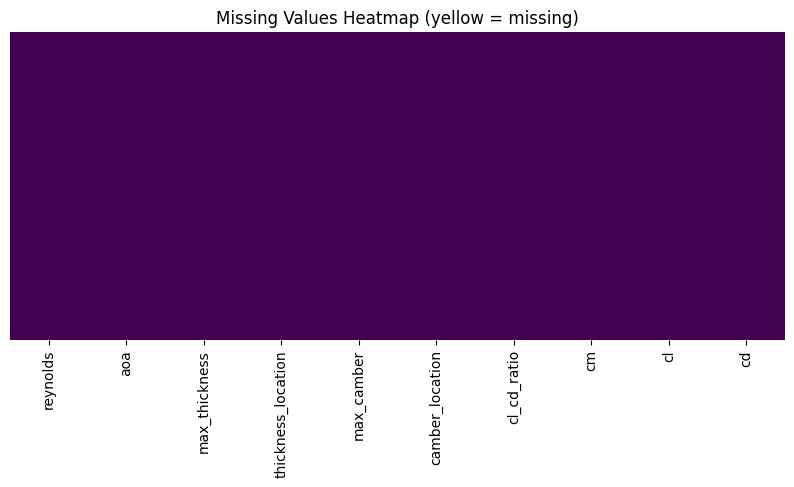

In [6]:
print("Missing values per column:")
print(df.isnull().sum())

print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Total rows: {len(df)}")

# Visualize missing values
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Heatmap (yellow = missing)")
plt.show()

In [7]:
print("Before cleaning:", df.shape)

# Cd (drag) can NEVER be negative in real life
df = df[df['cd'] > 0]

# Cl should be within realistic range (-3 to 3)
df = df[df['cl'].between(-3, 3)]

# Reynolds number should be positive
df = df[df['reynolds'] > 0]

# AoA should be within realistic range (-20 to 45 degrees)
df = df[df['aoa'].between(-20, 45)]

# Remove duplicate rows
df = df.drop_duplicates()

print("After cleaning:", df.shape)
print(f"Removed {178691 - len(df)} bad rows")

Before cleaning: (178691, 10)
After cleaning: (178216, 10)
Removed 475 bad rows


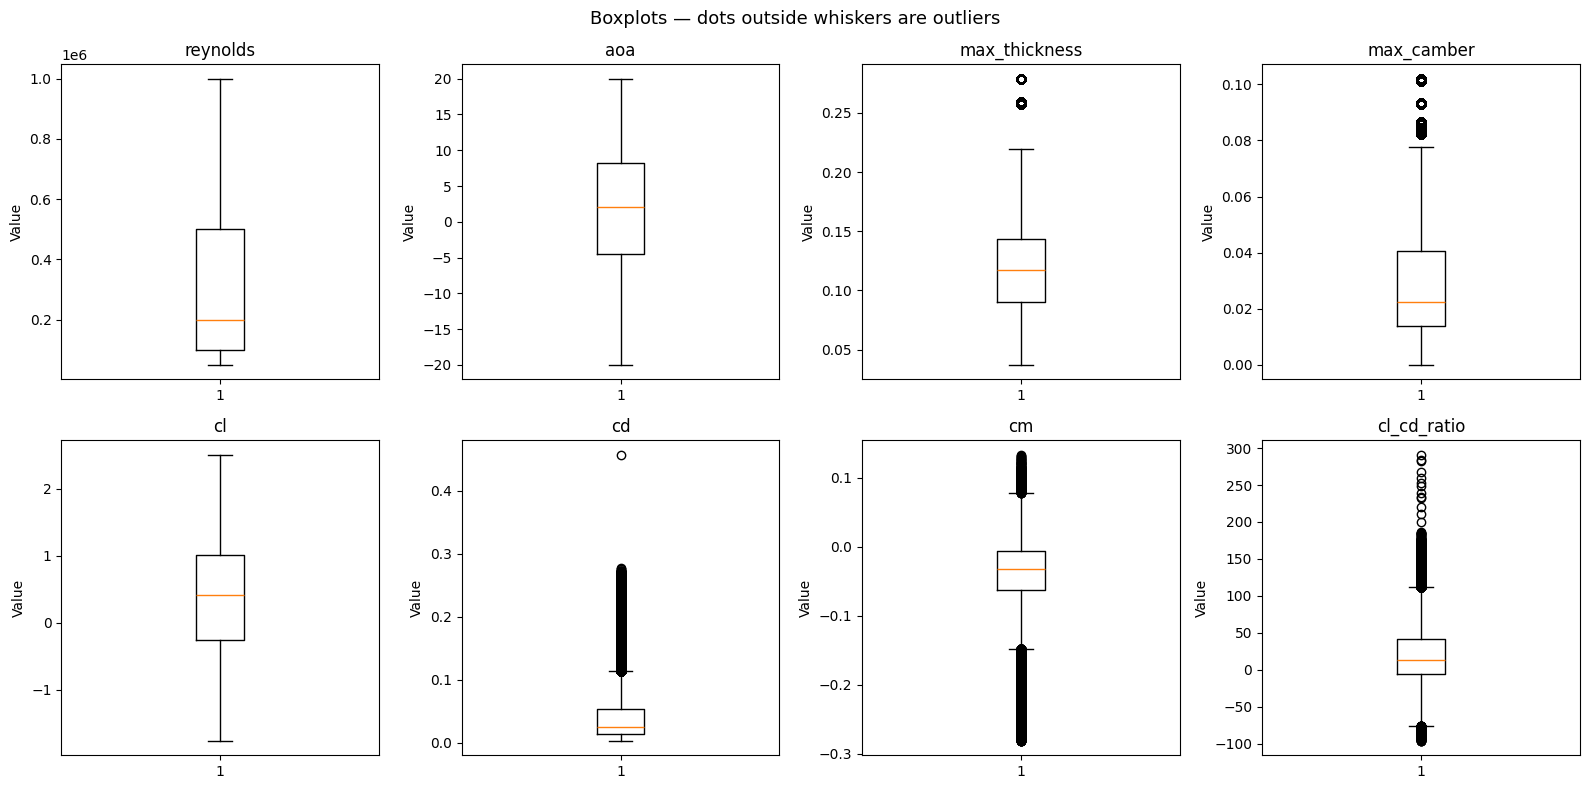

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

cols_to_plot = ['reynolds', 'aoa', 'max_thickness', 'max_camber',
                'cl', 'cd', 'cm', 'cl_cd_ratio']

for i, col in enumerate(cols_to_plot):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots — dots outside whiskers are outliers', fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    removed = 0
    
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)   # 25th percentile
        Q3 = df_clean[col].quantile(0.75)   # 75th percentile
        IQR = Q3 - Q1                        # Interquartile range
        
        lower = Q1 - 3 * IQR
        upper = Q3 + 3 * IQR
        
        before = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= lower) & 
                            (df_clean[col] <= upper)]
        removed += before - len(df_clean)
        print(f"{col}: removed {before - len(df_clean)} rows "
              f"| valid range: {lower:.4f} to {upper:.4f}")
        
    print(f"\nTotal removed: {removed} outlier rows")
    return df_clean

# Apply outlier removal
df = remove_outliers_iqr(df, ['cd', 'cm', 'cl_cd_ratio', 
                               'max_thickness', 'max_camber'])

print("\nAfter outlier removal:", df.shape)

cd: removed 1662 rows | valid range: -0.1058 to 0.1733
cm: removed 822 rows | valid range: -0.2320 to 0.1621
cl_cd_ratio: removed 21 rows | valid range: -146.4668 to 181.9583
max_thickness: removed 0 rows | valid range: -0.0714 to 0.3056
max_camber: removed 0 rows | valid range: -0.0652 to 0.1194

Total removed: 2505 outlier rows

After outlier removal: (175711, 10)


In [12]:
# Inputs (what the model learns FROM)
X = df[['reynolds', 'aoa', 'max_thickness', 
        'thickness_location', 'max_camber', 
        'camber_location', 'cm']]

# Outputs (what the model tries to PREDICT)
y = df[['cl', 'cd']]

print("Input shape (X):", X.shape)
print("Output shape (y):", y.shape)
print("\nInput features:", X.columns.tolist())
print("Output targets:", y.columns.tolist())

Input shape (X): (175711, 7)
Output shape (y): (175711, 2)

Input features: ['reynolds', 'aoa', 'max_thickness', 'thickness_location', 'max_camber', 'camber_location', 'cm']
Output targets: ['cl', 'cd']


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42     # so results are reproducible
)

print("Training set size:", X_train.shape)
print("Testing set size :", X_test.shape)
print(f"\n80% of data ({len(X_train)} rows) → model learns from this")
print(f"20% of data ({len(X_test)} rows) → model tested on this")

Training set size: (140568, 7)
Testing set size : (35143, 7)

80% of data (140568 rows) → model learns from this
20% of data (35143 rows) → model tested on this


In [14]:
preprocessing_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Step 1: fill missing values
    ('scaler', StandardScaler())                     # Step 2: normalize all values
])

# Fit on training data and transform both train and test
X_train_clean = preprocessing_pipeline.fit_transform(X_train)
X_test_clean  = preprocessing_pipeline.transform(X_test)

print("Pipeline applied!")
print("X_train_clean shape:", X_train_clean.shape)
print("X_test_clean shape :", X_test_clean.shape)

print("\nAfter scaling:")
print("Mean of each feature (should be ~0):", 
      X_train_clean.mean(axis=0).round(2))
print("Std of each feature  (should be ~1):", 
      X_train_clean.std(axis=0).round(2))

Pipeline applied!
X_train_clean shape: (140568, 7)
X_test_clean shape : (35143, 7)

After scaling:
Mean of each feature (should be ~0): [-0.  0.  0.  0. -0. -0.  0.]
Std of each feature  (should be ~1): [1. 1. 1. 1. 1. 1. 1.]


In [16]:
# Convert back to DataFrame with column names
X_train_df = pd.DataFrame(X_train_clean, columns=X.columns)
X_test_df  = pd.DataFrame(X_test_clean,  columns=X.columns)

# Reset index
y_train_reset = y_train.reset_index(drop=True)
y_test_reset  = y_test.reset_index(drop=True)

# Combine inputs + outputs
train_final = pd.concat([X_train_df, y_train_reset], axis=1)
test_final  = pd.concat([X_test_df,  y_test_reset],  axis=1)

# Save
train_final.to_csv('train_clean.csv', index=False)
test_final.to_csv('test_clean.csv',   index=False)

print("Saved!")
print(f"train_clean.csv → {len(train_final)} rows")
print(f"test_clean.csv  → {len(test_final)} rows")
print(f"Total columns   : {len(train_final.columns)}")
print(f"Columns         : {train_final.columns.tolist()}")

Saved!
train_clean.csv → 140568 rows
test_clean.csv  → 35143 rows
Total columns   : 9
Columns         : ['reynolds', 'aoa', 'max_thickness', 'thickness_location', 'max_camber', 'camber_location', 'cm', 'cl', 'cd']
